# Learning Rate, Gradient Checking and Consolidation

## 1. Retrieval

1. Write the gradient-descent update equations for the parameters $w$ and $b$.

> $$w_{i+1}=w_{i}-\eta \frac{\partial L}{\partial w}$$
>
> $$b_{i+1}=b_{i}-\eta \frac{\partial L}{\partial b}$$

2. What does $\eta$ control?

> The learning rate, which effects the size of the step taken in each iteration of the gradient descent algorithm.

3. What would you expect if $\eta$ is:
    - too small?

    > The optimisation/training proces takes longer

    - sensible?

    > Loss function will flatten after an appropriate number of cycles

    - too large?
    
    > The w and b gradients may not decrease smoothly, and the loss function may never flatten

4. Why does batch gradient descent recalculate the gradient every iteration?

> After changing parameters, we are at a new point on the loss surface, where the gradient's direction and magnitude may be different. We therefore recalculate it before deciding the next step.

5. What does it mean if the loss is decreasing but doing so extremely slowly?

> The learning rate, $\eta$, is too low

## 2. Recreate Session 3 dataset

Bring across the gradient descent functionused in the previous session:

In [1]:
import numpy as np

def predict(x, w, b):
    """
    Predicts the output y_hat based on equation y_hat = w * x + b

    Args:
        x (np.array(n)): vector containing n input arguements
        w (float): weight/slope parameter
        b (float): intercept parameter
    Returns:
        y_hat (np.array(n)): vector containing predicted values
    """

    y = w * x + b
    return y

def mse(y_true, y_pred):
    """
    Calculates the mean squared error between the predicted result and the true result

    Args:
        y_true (np.array(n)): vector containing true results
        y_pred (np.array(n)): vector containing predicted values
    Returns:
        mean_squared_error (float): mean squared error between predicted and true results
    """

    residual = y_true - y_pred
    mean_squared_error =  np.mean(residual**2)
    return mean_squared_error

def gradients(x, y, w, b):
    """
    Derives the w-gradient and b-gradients

    Args:
        x (np.array(n)): vector containing n input arguements
        y (np.array(n)): vector containing true results
        w (float): weight/slope parameter
        b (float): intercept parameter
    Returns:
        dw (float): gradient with respect to w
        db (float): gradient with respect to b
    """

    y_predicted = w * x + b
    residual = y_predicted - y

    dw = np.mean(2 * x * residual)
    db = np.mean(2 * residual)

    return dw, db

def gradient_descent(x, y, learning_rate, n_iterations):
    """
    Completes n_iterations of gradient descent starting with w=0, b=0

    Args:
        x (np.array(n)): vector containing n input arguements
        y (np.array(n)): vector containing true results
        learning_rate (float): scalar determining scale of step size taken in each iteration
        n_iterations (int): integer denoting the number of gradient descent iterations to complete
    Returns:
        w (float): final weight/slope paramater
        b (float): final intercept parameter
        loss_history (float[]): list of scalar losses
    """
    w = 0.0
    b = 0.0

    loss_history = []

    for i in range(n_iterations):
        # Calculate and update loss value before iterating w, b
        y_prediction = predict(x, w, b)
        loss = mse(y, y_prediction)
        loss_history.append(loss)

        # Calculate w-gradient and b-gradient
        dw, db = gradients(x, y, w, b)

        # Calculate folow up w and b values
        w_new = w - learning_rate * dw
        b_new = b - learning_rate * db

        # Update w and b
        w = w_new
        b = b_new

    final_loss = mse(y, predict(x, w, b))
    loss_history.append(final_loss)

    return w, b, loss_history


and recreate the same dataset:

In [2]:
rng = np.random.default_rng(42)

x = np.linspace(0, 10, 100)
noise = rng.normal(0, 2, size=x.shape)

y = 3 * x + 5 + noise

The previous run learned approximately: $$w\approx2.92,~~~b\approx5.29$$with a final MSE around $2.33$, so you already have a useful baseline.

## 3. Learning-rate comparison

Run the same fit with three learning rates and produce one loss-vs-iteration plot with labelled curves.

For your current dataset, use:

In [3]:
learning_rates = [0.001, 0.01, 0.03]
n_iterations = 1000

Store:
- final $w$
- final $b$
- loss history

Learning rate       Final w             Final b             Final loss          
1.000e-03           3.353e+00           2.414e+00           4.471e+00
1.000e-02           2.921e+00           5.286e+00           2.329e+00
3.000e-02           -7.923e+23           -1.191e+23           2.199e+49


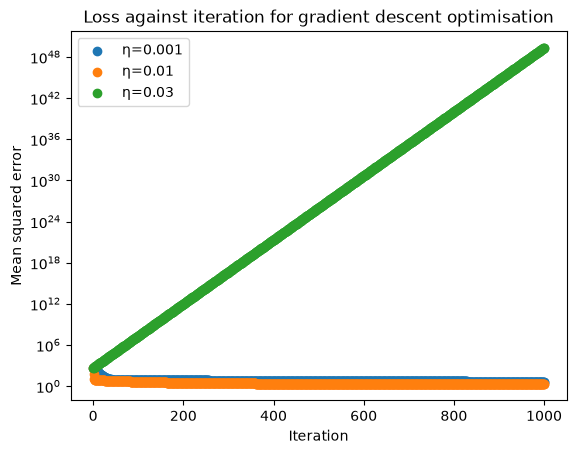

In [4]:
import matplotlib.pyplot as plt


final_ws = []
final_bs = []
loss_histories = []

iteration = np.arange(n_iterations + 1)
fig, ax = plt.subplots()

for learning_rate in learning_rates:
  w, b, loss_history = gradient_descent(x, y, learning_rate, n_iterations)
  final_ws.append(w)
  final_bs.append(b)
  loss_histories.append(loss_history)

  ax.scatter(iteration, loss_history, label=f'η={learning_rate}')

ax.set_yscale('log')
ax.set_title('Loss against iteration for gradient descent optimisation')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean squared error')
ax.legend()

print('Learning rate       Final w             Final b             Final loss          ')
for i in range(len(learning_rates)):
  print(f'{learning_rates[i]:.3e}           {final_ws[i]:.3e}           {final_bs[i]:.3e}           {(loss_histories[i])[-1]:.3e}')


### Results

| Learning rate | Final w | Final b | Final loss | Behaviour |
| ------------- | ------: | ------: | ---------: | --------- |
| 0.001         |     3.35 |     2.41 |        4.47 | Converges but slowly       |
| 0.01          |     2.92 |     5.29 |        2.33 | Converges and flattens quickly       |
| 0.03          |     -7.92e+23 |     -1.19e+23 |        2.20e+49 | MSE diverges and increases exponentially       |


### Answer:
1. Which learning rate is slow?

> 0.001 is slow. After 1000 iterations the loss for the $\eta=0.001$ model is higher than that of the $\eta=0.01$

2. Which gives useful convergence?

> $\eta=0.01$ is the most useful as the convergence happens quickly, however $\eta=0.001$ also converges, just more slowly

3. Which diverges?

> $\eta=0.03$ diverges

4. What is happening geometrically when the learning rate is too large?

> With a large learning rate the gradient risks jumping between a positive slope and a negative slope after each iteration, meaning the sign for $\nabla L$ will flip each iteration. This will result in the loss function moving away from the local minimum with each subsequent step, leading to larger and larger swings in the calculated parameter values as the error value diverges away from the minimum

> **Correction**: A too-large step can overshoot the minimum, possibly causing oscillation; if the overshoots grow, the parameters and loss diverge.

5. Why can a very small learning rate still eventually work?

> For this convex linear-regression problem, given enough iterations a very small learning rate will eventually reach the same final parameters as an optimal learning rate, however this is inefficient. 

## 4. Revisit Optimisation Using Gradient Descent Textbook

Reopen
[Mathematics for Machine Learning](https://mml-book.github.io/book/mml-book.pdf?utm_source=chatgpt.com), Chapter 7, §7.1.

Only revisit the discussion around step size / gradient descent. Do not reread the entire chapter.

Write two sentences:

- The gradient determines:

> The direction on the loss surface of steepest increase, therefore the negative gradient used in the loss function points in the direction of steepest decrease, i.e. the direction required to locally minimise the loss function.

- The learning rate determines:

> Determines the size of the step taken in each iteration of gradient descent by scaling the gradient in the equations:$$\theta_{i+1}=\theta_{i}-\eta \nabla L(\theta)$$ If it is too small, gradient descent can be slow, however if it is too large, gradient descent can overshoot, fail to converge, or even diverge. 

The distinction I want secure is:

$$ \text{gradient} \neq \text{learning rate} $$

The gradient provides direction and local slope information; the learning rate controls how strongly you act on it.

## 5. Gradient checking

Your analytical gradients are already:

$$ \frac{\partial L}{\partial w} $$

and:

$$ \frac{\partial L}{\partial b}. $$

Now we want to estimate those derivatives without using your gradient formulas.

For a one-variable function, a small finite distance approximation is:

$$f'(x)\approx \frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon}$$

That is a **central finite difference**. The specific implementation details goes slightly beyond the scope of this session, but it is a clean way to perform the numerical check requested there.

For $w$:

$$\frac{\partial L}{\partial w}\approx \frac{L(w+\varepsilon,b)-L(w-\varepsilon,b)}{2\varepsilon}$$

while $b$ remains fixed.

Likewise for $b$:

$$\frac{\partial L}{\partial b}\approx \frac{L(w,b+\varepsilon)-L(w,b-\varepsilon)}{2\varepsilon}$$

while $w$ remains fixed.

Use:

In [5]:
epsilon = 1e-5

w_test = 2.0
b_test = 4.0

### Exercise

Write;

```
def numerical_gradients(x, y, w, b, epsilon):
    ...
```

Return:
```
dw_numerical, db_numerical
```

Do **not** call your existing `gradients()` from inside the function.

Instead, use only:
- `predict()`
- `mse()`
- small perturbations of $w$ and $b$

Then compare:
```
Analytical dw: ...
Numerical dw: ...
Analytical db: ...
Numerical db: ...
dw matches: ...
db matches: ...
```

In [6]:
def numerical_gradients(x, y, w, b, epsilon):
    """
    Calculates the w and b-gradients using the central finite difference formula

    Args:
        x (np.array(n)): vector containing n input arguements
        y (np.array(n)): vector containing true results
        w (float): weight/slope paramater
        b (float): intercept parameter
        epsilon (float): distance between sample points
    Return:
        dw_numerical (float): numerically calculated gradient with respect to w
        db_numerical (float): numerically calculated gradient with respect to b
    """

    dw_numerical = (mse(y, predict(x, w + epsilon, b)) - mse(y, predict(x, w - epsilon, b))) / (2 * epsilon)
    db_numerical = (mse(y, predict(x, w, b + epsilon)) - mse(y, predict(x, w, b - epsilon))) / (2 * epsilon)

    return dw_numerical, db_numerical

In [7]:
dw_analytical, db_analytical = gradients(x, y, w_test, b_test)
dw_numerical, db_numerical = numerical_gradients(x, y, w_test, b_test, epsilon)

print('Analytical dw:', dw_analytical)
print('Numerical dw:', dw_numerical)
print('Analytical db:', db_analytical)
print('Numerical db', db_numerical)
print('dw matches:', np.allclose(dw_analytical, dw_numerical))
print('db matches:', np.allclose(db_analytical, db_numerical))

Analytical dw: -74.57129581507834
Numerical dw: -74.57129581531774
Analytical db: -11.798921554064568
Numerical db -11.79892155391826
dw matches: True
db matches: True


### Interpretation

Answer:

Why is agreement between these two methods useful evidence that the analytical gradient implementation is correct?

> The analytical gradient and finite-difference gradient are calculated using independent methods. If they give approximately the same result, this is evidence that the derived gradient formula and its code implementation are correct.

And:

Why would a gradient check be especially useful for a much more complicated model?

> Complicated models can contain many derivatives, making mistakes in analytical or backpropagation implementations difficult to spot. Comparing selected analytical gradients against numerical finite-difference estimates provides a way to detect those errors.

> **Note**: Numerical gradients are generally a **checking tool**, not a replacement for analytical gradients during training. Finite differences become extremely expensive when there are many parameters.

## 6. Feature-scaling intuition

Use the same dataset, but make:

In [8]:
x_scaled = x / 10

Do not change `y`.

Now compare what happens with:

In [9]:
learning_rate = 0.03

for `x` versus `x_scaled`.

Before running it, predict: do you expect the learning rate to behave identically?

> I predict the `learning_rate = 0.03` to converge with the `x_scaled` dataset but to diverge with the non-scaled dataset

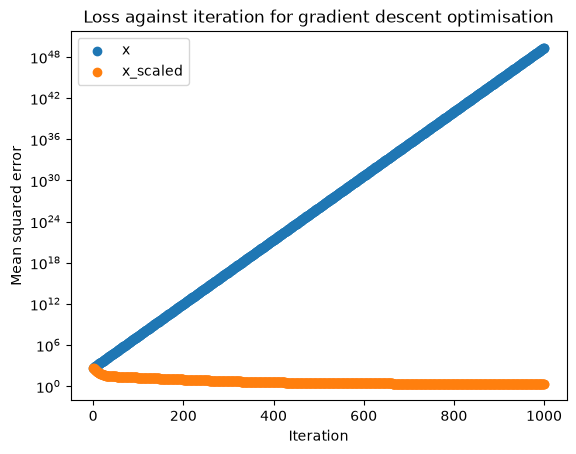

In [10]:
w, b, loss_history = gradient_descent(x, y, learning_rate, n_iterations)
w_scaled, b_scaled, loss_history_scaled = gradient_descent(x_scaled, y, learning_rate, n_iterations)

fig, ax = plt.subplots()
ax.scatter(iteration, loss_history, label='x')
ax.scatter(iteration, loss_history_scaled, label='x_scaled')

ax.set_yscale('log')
ax.set_title('Loss against iteration for gradient descent optimisation')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean squared error')
ax.legend()

### Answer

1. Did scaling $x$ change the stability of gradient descent?

> Yes, the gradient descent converge to a stable loss minimum

2. Why does changing the magnitude of $x_i$ affect:

$$ \frac{\partial L}{\partial w} = \frac{2}{n}\sum x_i(\hat y_i-y_i)? $$

> Changing the magnitude of $x$ (and not $y$) will effect how the result of $x_i(\hat{y_i}-y_i)$ is scaled, which will result in a scaling effect on the $w$-gradient. Scaling $x$ changes the scale of the $w$-gradient, so the same $\eta$ produces differently sized parameter updates.

3. Why can differently scaled features make one learning rate awkward in a model with several parameters?

> The learning rate needs to work across all parameter-gradients, therefore this could be difficult if the model uses multiple variables with significantly different scalings. Perhaps standardisng all model features before training could solve this issue?

## 7. Scikit-learn sanity check

This is a verification step rather than new optimisation theory.

Fit:
```
LinearRegression()
```
to the same original `x, y`.

Remember scikit-learn expects feature data to be 2D, so reason about why:

```
x.shape
```
and
```
x.reshape(-1, 1).shape
```
are different before fitting

> Because x.reshape(-1, 1) reshapes the x array into a 2D array since scikit-learn expectes 2D data, whereas x is intially a 1D array before reshaping

Compare:

```
My gradient descent w: ...
sklearn coefficient: ...

My gradient descent b: ...
sklearn intercept: ...
```


In [11]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(x.reshape(-1, 1), y.reshape(-1, 1))

print(f'My gradient descent w: {final_ws[1]:.3f}')
print(f'sklearn coefficient: {(regr.coef_[0])[0]:.3f}')
print(f'\nMy gradient descent b: {final_bs[1]:.3f}')
print(f'sklearn intercept: {regr.intercept_[0]:.3f}')


My gradient descent w: 2.921
sklearn coefficient: 2.916

My gradient descent b: 5.286
sklearn intercept: 5.319


Then answer:

    Why should the values be very close even though scikit-learn did not use your gradient-descent loop?

> Both methods minimise the same least-squares objective. `LinearRegression` solves the least-squares problem directly using linear-algebra methods, while gradient descent approaches the same minimum iteratively. If gradient descent has converged sufficiently, their fitted parameters should therefore be very close.

## 8. Final calculus/optimisation retrieval

1. What does a derivative represent?

> The instantaneous rate of change of a one-variable function with respect to its input; geometrically, the slope of the tangent to the curve at that point

2. What is a partial derivative?

> The derivative of a multivariable function with respect to one variable while all the other variables are fixed

3. What does a gradient represent?

> A vector containing all the partial derivatives of a scalar-valued multivariable function. It points in the direction of steepest local increase, and its magnitude describes the rate of increase in that direction

4. Why do we move in the negative gradient direction?

> In gradient descent we move in the negative gradient direction because we want to reach the local minimum of the objective function, therefore following the negative of the direction of steepest increase will move in the direction of steepest decrease, which is useful for minimising the objective function result

5. What does the learning rate control?

> The step size taken in each iteration of gradient descent

6. What happens when the learning rate is too large?

> If learning rate is too large, gradient descent can overshoot, fail to converge, or even diverge

7. What is the difference between a local and global minimum?

> A local minimum is only lower than its nearby points while the global minimum is lower than every other point in the domain

8. What does convexity tell you about a stationary point?

> For a differentiable convex function, any stationary point is a global minimum. Convexity alone does not necessarily mean that minimum is unique; strict convexity gives uniqueness

9. Write the MSE for:
$$ \hat y=wx+b. $$

> $$MSE=\frac{1}{n}\sum_{i=1}^n(\hat{y_i}-y_i)^2$$

10. Write:
$$ \frac{\partial L}{\partial w}, \qquad \frac{\partial L}{\partial b}. $$

> $$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}x_i(\hat{y_i}-y_i)$$
> $$\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)$$

11. Explain batch gradient descent from beginning to end.

> 1. Initial values for $w,b$ parameters are set
> 2. Prediction are made based on the input data and these parameter values according to $\hat{y}=wx+b$
> 3. Calculate the $w$-gradient and $b$-gradient using:
> $$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}x_i(\hat{y_i}-y_i),$$
> $$\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)$$
> 4. New paramater values are calculated using:
> $$w_{new}=w_{old}-\eta\frac{\partial L}{\partial w},$$
> $$b_{new}=b_{old}-\eta\frac{\partial L}{\partial b}$$
> where $\eta$ is the learning rate
> 5. These new parameter values are used to make new predictions and recalculate the loss (MSE)
> 6. Return to step 2 and repeat for n iterations. With a suitable learning rate $\eta$, repeatedly applying these updates should converge the MSE to a minimum value.

> This algorithm is called batch gradient descent because each gradient calculation uses all observations in the dataset

12. What is a numerical gradient check?

> Comparing the analytical gradient results against the numerical approximations for gradient which uses a small finite distance approximation.

13. Why can feature scaling affect optimisation?

> Scaling a feature will affect any gradients that depend on that feature, therefore the gradient descent calculation will result in a different step size in each iteration of gradient descent. This means that for a given learning rate, differently scaled features may produce different behaviours (such as diverging instead of converging) when optimised with gradient descent 

14. Why might gradient descent and scikit-learn produce essentially the same linear-regression parameters by different methods?

> Both scikit-learn LinearRegression and gradient descent will find the same optimal weights for a linear model because LinearRegression computes an exact solution directly, while gradient descent steps along the steepest gradient regions to eventually converge at the global optimum, but both methods are essentially asking the same question just using different methods.